# ЛЦТ 2026. Модель месячного риска зарегистрированной неисправности

**Постановка:** в полночь оцениваем риск хотя бы одного нового зарегистрированного эпизода «Неисправен» в интервале **[t + 24 часа, t + 31 день)**. Это 30 полных суток после первых 24 часов, ориентир для планирования обслуживания.

**Это отдельная постановка.** Для прежнего окна 24-48 часов целевые метрики не достигнуты. Мы не переносим результат месячного прогноза на суточный.
Разметка описывает состояние в журнале; независимого подтверждения физической поломки датчика нет. При прогнозе текущее известное состояние должно быть «Норма».

**Статус оценки:** 2026 год уже анализировался при разработке предыдущих вариантов. Ниже выполняем ретроспективную временную проверку, а не заявляем новый слепой test. Для независимого подтверждения нужен новый период или скрытый набор организаторов.

Обучение включает данные до середины 2025 года. Выбор модели выполняем на июле-августе 2025, порога на октябре-ноябре. Между ролями учитываем весь 31-дневный горизонт.

## Запуск
Положим ноутбук рядом с `data_handoff` из финального EDA либо изменим `HANDOFF`. Выполним Restart Kernel and Run All. Внешний Python-модуль и предыдущий ML-ноутбук для обучения не нужны.
В `planning_artifacts` сохраняются модель, функция прогноза, отчёты и кеши. Исходные данные не изменяются.

In [1]:
# %pip install pandas numpy matplotlib pyarrow duckdb scikit-learn lightgbm joblib

In [2]:
from pathlib import Path
import os,json,time,gc,hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import lightgbm as lgb
from IPython.display import display,Markdown
HANDOFF=Path(os.environ.get('LCT_HANDOFF_DIR','data_handoff')).resolve()
OUT=Path(os.environ.get('LCT_MODEL_OUTPUT','planning_artifacts')).resolve()
FORCE_TRAIN=False
for folder in ['cache','experiments','reports','figures','bundle']:(OUT/folder).mkdir(parents=True,exist_ok=True)
pd.set_option('display.max_columns',16)
plt.rcParams.update({'figure.figsize':(11,4),'axes.grid':True,'grid.alpha':.2})
spec=json.loads((HANDOFF/'feature_list.json').read_text(encoding='utf-8'))
manifest=json.loads((HANDOFF/'final_run_manifest.json').read_text(encoding='utf-8'))
assert manifest['all_checks_passed']
base_features=spec['features']
input_names=['feature_list.json','final_run_manifest.json','episodes/fault_episodes.parquet','calendar_coverage.parquet','ml_ready/train.parquet','ml_ready/validation.parquet','ml_ready/test.parquet']
data_key=hashlib.sha256(json.dumps(['monthly-recent-v1',[(f,(HANDOFF/f).stat().st_size,(HANDOFF/f).stat().st_mtime_ns) for f in input_names]]).encode()).hexdigest()[:16]
CACHE=OUT/'cache'/data_key;EXPERIMENTS=OUT/'experiments'/data_key
CACHE.mkdir(exist_ok=True);EXPERIMENTS.mkdir(exist_ok=True)

## 1. Функции обработки и прогноза

Технические функции свёрнуты. В следующих разделах показываем их результаты на таблицах и графиках. Все дополнительные признаки строятся только по прошлым событиям, длительности доступны после завершения эпизода.

In [3]:
from pathlib import Path
import gc
import hashlib
import json
import time
import numpy as np
import pandas as pd
import duckdb
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
from sklearn.metrics import precision_score, recall_score, f1_score, brier_score_loss, log_loss
from sklearn.linear_model import LogisticRegression
FEATURE_VERSION = 'episodes-past-v2'
TARGET = 'target_monthly'
EPISODE_WINDOWS = [1, 7, 30, 90, 365]
FORBIDDEN = {'last_seen', 'target_fault_0_24h', TARGET, 'channel_followup_48h',
             'global_complete_24_48h', 'target_start', 'target_end', 'sample_weight',
             'sampling_probability', 'sensor_type_current', 'object_id_current',
             'system_type_current', 'channel_id', 'prediction_time'}

In [4]:
def sql_path(path):
    return "'" + str(path).replace('\\', '/').replace("'", "''") + "'"

In [5]:
def episode_tables(con, path):
    con.execute(f"""CREATE OR REPLACE TEMP TABLE starts_prefix AS
    WITH daily AS (
      SELECT channel_id, CAST(start_ts AS DATE) AS day, count(*) AS n,
             max(start_ts) AS last_start
      FROM read_parquet({sql_path(path)}) WHERE observed_start
      GROUP BY channel_id, CAST(start_ts AS DATE)
    ) SELECT *, sum(n) OVER(PARTITION BY channel_id ORDER BY day) AS cumulative,
        count(*) OVER(PARTITION BY channel_id ORDER BY day) AS cumulative_days
      FROM daily ORDER BY channel_id, day""")
    con.execute(f"""CREATE OR REPLACE TEMP TABLE closes_prefix AS
    WITH daily AS (
      SELECT channel_id, CAST(end_ts AS DATE) AS day, count(*) AS n,
        count(*) FILTER(WHERE duration_hours <= 1.0/60) AS short_n,
        sum(ln(1+duration_hours)) AS log_duration_sum, max(end_ts) AS last_close
      FROM read_parquet({sql_path(path)})
      WHERE observed_start AND end_ts IS NOT NULL AND duration_hours >= 0
      GROUP BY channel_id, CAST(end_ts AS DATE)
    ) SELECT *, sum(n) OVER w AS cumulative,
        sum(short_n) OVER w AS short_cumulative,
        sum(log_duration_sum) OVER w AS duration_cumulative
      FROM daily WINDOW w AS (PARTITION BY channel_id ORDER BY day)
      ORDER BY channel_id, day""")

In [6]:
def episode_select(source):
    fields = ["r.*", "epoch(r.prediction_time-s0.last_start)/3600 AS hours_since_fault_start",
              "epoch(r.prediction_time-c0.last_close)/3600 AS hours_since_fault_end",
              "greatest(s0.last_start,c0.last_close) AS episode_feature_max_ts"]
    joins = ["ASOF LEFT JOIN starts_prefix s0 ON r.channel_id=s0.channel_id AND r.prediction_time>s0.day",
             "ASOF LEFT JOIN closes_prefix c0 ON r.channel_id=c0.channel_id AND r.prediction_time>c0.day"]
    for days in EPISODE_WINDOWS:
        fields.append(f"coalesce(s0.cumulative,0)-coalesce(s{days}.cumulative,0) AS fault_starts_{days}d")
        fields.append(f"coalesce(s0.cumulative_days,0)-coalesce(s{days}.cumulative_days,0) AS fault_start_days_{days}d")
        joins.append(f"ASOF LEFT JOIN starts_prefix s{days} ON r.channel_id=s{days}.channel_id AND r.prediction_time-INTERVAL {days} DAY>s{days}.day")
    for days in [6, 13, 20, 27]:
        fields.append(f"CASE WHEN w{days}.n IS NULL THEN 0 ELSE 1 END AS fault_day_lag_{days}")
        joins.append(f"LEFT JOIN starts_prefix w{days} ON r.channel_id=w{days}.channel_id AND CAST(r.prediction_time-INTERVAL {days} DAY AS DATE)=w{days}.day")
    for days in [30, 90]:
        fields += [f"coalesce(c0.cumulative,0)-coalesce(c{days}.cumulative,0) AS fault_closes_{days}d",
                   f"coalesce(c0.short_cumulative,0)-coalesce(c{days}.short_cumulative,0) AS short_fault_closes_{days}d",
                   f"(coalesce(c0.duration_cumulative,0)-coalesce(c{days}.duration_cumulative,0))/nullif(coalesce(c0.cumulative,0)-coalesce(c{days}.cumulative,0),0) AS past_log_duration_mean_{days}d"]
        joins.append(f"ASOF LEFT JOIN closes_prefix c{days} ON r.channel_id=c{days}.channel_id AND r.prediction_time-INTERVAL {days} DAY>c{days}.day")
    return 'SELECT ' + ', '.join(fields) + ' FROM ' + source + ' r ' + ' '.join(joins)

In [7]:
def add_episode_file(con, source, destination):
    source_sql = f'read_parquet({sql_path(source)})'
    keys_sql = f'(SELECT channel_id,prediction_time FROM {source_sql})'
    query = f'WITH augmented AS ({episode_select(keys_sql)}) SELECT r.*, a.* EXCLUDE(channel_id,prediction_time) FROM {source_sql} r JOIN augmented a USING(channel_id,prediction_time)'
    temporary = Path(destination).with_suffix('.partial.parquet')
    con.execute(f'COPY ({query}) TO {sql_path(temporary)} (FORMAT PARQUET, COMPRESSION ZSTD)')
    temporary.replace(destination)
    bad = con.execute(f"SELECT count(*) FROM read_parquet({sql_path(destination)}) WHERE episode_feature_max_ts>=prediction_time").fetchone()[0]
    if bad:
        raise ValueError('Обнаружена будущая информация в признаках эпизодов')

In [8]:
def augmented_feature_names(base_features):
    episode = ['hours_since_fault_start', 'hours_since_fault_end']
    episode += [f'fault_starts_{d}d' for d in EPISODE_WINDOWS]
    episode += [f'fault_start_days_{d}d' for d in EPISODE_WINDOWS]
    episode += [f'fault_day_lag_{d}' for d in [6, 13, 20, 27]]
    episode += [f'{stem}_{d}d' for d in [30, 90]
                for stem in ['fault_closes', 'short_fault_closes', 'past_log_duration_mean']]
    ratios = ['hours_since_explicit_state', 'alarm_share_1d', 'fault_share_7d',
              'undefined_share_7d', 'night_share_7d', 'numeric_share_7d',
              'events_per_active_day_7d', 'events_per_active_day_30d',
              'numeric_range_7d', 'numeric_range_30d', 'short_fault_share_90d',
              'fault_start_ratio_7d_30d', 'fault_day_rate_30d', 'fault_day_rate_90d',
              'fault_day_rate_365d', 'starts_per_fault_day_30d', 'fault_weekly_repeats']
    result = list(dict.fromkeys(list(base_features) + episode + ratios))
    if set(result) & FORBIDDEN:
        raise ValueError('Служебное поле попало в признаки')
    return result

In [9]:
def feature_matrix(frame, names):
    d = frame.copy(deep=False)
    d = d.assign(hours_since_explicit_state=(pd.to_datetime(d['prediction_time'])-pd.to_datetime(d['last_state_ts'])).dt.total_seconds()/3600)
    ratios = {'alarm_share_1d':('alarms_1d','events_1d'),
              'fault_share_7d':('fault_messages_7d','events_7d'),
              'undefined_share_7d':('undefined_messages_7d','events_7d'),
              'night_share_7d':('night_events_7d','events_7d'),
              'numeric_share_7d':('numeric_n_7d','events_7d'),
              'events_per_active_day_7d':('events_7d','active_days_7d'),
              'events_per_active_day_30d':('events_30d','active_days_30d'),
              'starts_per_fault_day_30d':('fault_starts_30d','fault_start_days_30d'),
              'short_fault_share_90d':('short_fault_closes_90d','fault_closes_90d')}
    for name, (a,b) in ratios.items():
        d[name] = d[a] / d[b].replace(0,np.nan)
    for days in [7,30]:
        d[f'numeric_range_{days}d'] = d[f'numeric_max_{days}d']-d[f'numeric_min_{days}d']
    d['fault_start_ratio_7d_30d'] = (d['fault_starts_7d']/7)/(d['fault_starts_30d']/30).replace(0,np.nan)
    for days in [30, 90, 365]:
        d[f'fault_day_rate_{days}d'] = d[f'fault_start_days_{days}d']/days
    d['fault_weekly_repeats'] = d[[f'fault_day_lag_{days}' for days in [6, 13, 20, 27]]].sum(axis=1)
    x = d.loc[:,names].replace([np.inf,-np.inf],np.nan).astype('float32')
    if set(x) & FORBIDDEN:
        raise ValueError('Запрещённый признак')
    return x

In [10]:
def load_frame(path, con, where=None):
    q = f'SELECT * FROM read_parquet({sql_path(path)})'
    if where:
        q += ' WHERE ' + where
    frame = con.execute(q).fetchdf()
    for c in frame:
        if frame[c].dtype == 'float64':
            frame[c] = frame[c].astype('float32')
    for c in ['sensor_type_current','object_id_current','system_type_current','last_explicit_state']:
        if c in frame:
            frame[c] = frame[c].astype('category')
    return frame

In [11]:
def threshold_table(y, p):
    precision, recall, thresholds = precision_recall_curve(y,p)
    out = pd.DataFrame({'threshold':thresholds,'precision':precision[:-1],'recall':recall[:-1]})
    out['f1'] = 2*out.precision*out.recall/(out.precision+out.recall).replace(0,np.nan)
    out['f1'] = out['f1'].fillna(0)
    return out

In [12]:
def select_threshold(y,p):
    t = threshold_table(y,p)
    feasible = t.loc[(t.precision>0.7)&(t.recall>0.5)]
    reason = 'precision>0.7 and recall>0.5' if len(feasible) else 'max F1; joint requirement unattainable on this validation block'
    chosen = (feasible if len(feasible) else t).sort_values(['f1','precision','recall'],ascending=False).iloc[0]
    return float(chosen.threshold),reason

In [13]:
def score_metrics(y,p,threshold):
    y = np.asarray(y,dtype=int); p=np.asarray(p,dtype=float)
    positive = p>=threshold
    tp=int(np.sum(positive & (y==1))); fp=int(np.sum(positive & (y==0)))
    fn=int(np.sum(~positive & (y==1))); tn=int(np.sum(~positive & (y==0)))
    return {'rows':len(y),'positives':int(y.sum()),'prevalence':float(y.mean()),
            'average_precision':float(average_precision_score(y,p)) if y.sum() else None,
            'roc_auc':float(roc_auc_score(y,p)) if len(np.unique(y))==2 else None,
            'precision':float(precision_score(y,positive,zero_division=0)),
            'recall':float(recall_score(y,positive,zero_division=0)),
            'f1':float(f1_score(y,positive,zero_division=0)),
            'alerts':int(positive.sum()),'tp':tp,'fp':fp,'fn':fn,'tn':tn,
            'threshold':float(threshold)}

In [14]:
def probability_metrics(y,p):
    p=np.clip(np.asarray(p,dtype=float),1e-8,1-1e-8)
    return {'brier':float(brier_score_loss(y,p)), 'log_loss':float(log_loss(y,p,labels=[0,1]))}

In [15]:
def candidate_summary(y,p):
    t=threshold_table(y,p)
    at_p=t.loc[t.precision>0.7]
    at_r=t.loc[t.recall>0.5]
    return {'average_precision':float(average_precision_score(y,p)),
            'recall_at_precision_gt_07':float(at_p.recall.max()) if len(at_p) else 0.,
            'precision_at_recall_gt_05':float(at_r.precision.max()) if len(at_r) else 0.,
            'feasible':bool(((t.precision>0.7)&(t.recall>0.5)).any()),
            'max_f1':float(t.f1.max())}

In [16]:
def apply_calibration(p, calibration):
    p=np.clip(np.asarray(p,dtype=float),1e-8,1-1e-8)
    z=np.log(p/(1-p))*calibration['coef']+calibration['intercept']
    return 1/(1+np.exp(-np.clip(z,-50,50)))

In [17]:
def fit_calibration(y,p):
    clipped=np.clip(p,1e-8,1-1e-8)
    z=np.log(clipped/(1-clipped)).reshape(-1,1)
    model=LogisticRegression(C=10,max_iter=200,solver='lbfgs').fit(z,y)
    coefficient=float(model.coef_[0,0])
    if coefficient<=0:
        return {'coef':1.,'intercept':0.,'method':'identity; fitted slope nonpositive'}
    return {'coef':coefficient,'intercept':float(model.intercept_[0]),'method':'sigmoid logit, chronological calibration block'}

In [18]:
def predict_probability(model, x, features, kind):
    if kind=='lightgbm_native':
        return np.asarray(model.predict(x[features],num_threads=8),dtype='float32')
    if kind=='catboost':
        return np.asarray(model.predict_proba(x[features],thread_count=8)[:,1],dtype='float32')
    return np.asarray(model.predict_proba(x[features])[:,1],dtype='float32')

In [19]:
def cluster_intervals(frame, p, threshold, repeats=400, seed=2026):
    pred=np.asarray(p)>=threshold; y=frame[TARGET].to_numpy()
    counts=pd.DataFrame({'channel_id':frame.channel_id.astype(str),'tp':pred&(y==1),
                         'fp':pred&(y==0),'fn':~pred&(y==1)})
    groups=counts.groupby('channel_id')[['tp','fp','fn']].sum().to_numpy(dtype=float)
    rng=np.random.default_rng(seed); values=[]
    for _ in range(repeats):
        a,b,c=groups[rng.integers(0,len(groups),len(groups))].sum(axis=0)
        precision=a/(a+b) if a+b else np.nan
        recall=a/(a+c) if a+c else np.nan
        values.append([precision,recall,2*a/(2*a+b+c) if 2*a+b+c else np.nan])
    limits=np.nanquantile(values,[.025,.975],axis=0)
    return pd.DataFrame({'metric':['precision','recall','f1'],'low_95':limits[0],'high_95':limits[1]})

In [20]:
def reliability_table(y,p,bins=10):
    df=pd.DataFrame({'y':np.asarray(y),'p':np.asarray(p)})
    df['bin']=pd.qcut(df.p,q=bins,duplicates='drop')
    return df.groupby('bin',observed=True).agg(rows=('y','size'),mean_probability=('p','mean'),event_rate=('y','mean')).reset_index()

In [21]:
def score_subgroups(frame,p,threshold,column):
    data=frame[[column,TARGET]].copy()
    data['p']=p
    rows=[]
    for group,part in data.groupby(column,observed=True,dropna=False):
        rows.append({'group':str(group),**score_metrics(part[TARGET],part.p,threshold)})
    return pd.DataFrame(rows)

In [22]:
def load_bundle(directory):
    directory=Path(directory)
    config=json.loads((directory/'model_config.json').read_text(encoding='utf-8'))
    if config.get('target') != TARGET:
        raise ValueError('Модель предназначена для другого таргета')
    if config['feature_version'] != FEATURE_VERSION:
        raise ValueError('Версия обработки признаков не совпадает с версией модели')
    if config['kind']=='lightgbm':
        import lightgbm as lgb
        model=lgb.Booster(model_str=(directory/'model.txt').read_text(encoding='utf-8'))
        kind='lightgbm_native'
    elif config['kind']=='catboost':
        from catboost import CatBoostClassifier
        model=CatBoostClassifier();model.load_model(str(directory/'model.cbm'))
        kind='catboost'
    else:
        import joblib
        model=joblib.load(directory/'model.joblib');kind='logistic'
    return model,config,kind

In [23]:
def predict_batch(frame, episodes_path, model_directory):
    model,config,kind=load_bundle(model_directory)
    required=set(config['base_features'])|{'channel_id','prediction_time','last_state_ts','at_risk_with_history'}
    missing=required-set(frame.columns)
    if missing:
        raise ValueError('Отсутствуют обязательные поля: '+', '.join(sorted(missing)))
    data=frame.copy()
    data['prediction_time']=pd.to_datetime(data.prediction_time)
    data['last_state_ts']=pd.to_datetime(data.last_state_ts)
    if data.channel_id.isna().any():
        raise ValueError('Идентификатор канала не должен быть пустым')
    if data.prediction_time.isna().any() or not (data.prediction_time==data.prediction_time.dt.normalize()).all():
        raise ValueError('Нужен момент прогноза в полночь локального времени источника')
    if data.duplicated(['channel_id','prediction_time']).any():
        raise ValueError('Повторные ключи канал и момент прогноза')
    eligible=data.at_risk_with_history.eq(True)
    if data.loc[eligible,'last_state_ts'].isna().any():
        raise ValueError('Для применимого канала нужно время последнего явного состояния')
    if (data.loc[eligible,'last_state_ts']>=data.loc[eligible,'prediction_time']).any():
        raise ValueError('Время состояния должно быть строго раньше прогноза')
    if 'feature_max_ts' in data:
        if (pd.to_datetime(data.loc[eligible,'feature_max_ts'])>=data.loc[eligible,'prediction_time']).any():
            raise ValueError('Признаки содержат события после границы прогноза')
    answer=data[['channel_id','prediction_time']].copy()
    answer['risk_probability']=np.nan
    answer['alert']=pd.Series(pd.NA,index=answer.index,dtype='boolean')
    answer['status']=np.where(eligible,'scored','not_eligible')
    answer['model_version']=config['model_version']
    answer['target_start']=answer.prediction_time+pd.Timedelta(hours=config['window_hours'][0])
    answer['target_end']=answer.prediction_time+pd.Timedelta(hours=config['window_hours'][1])
    if eligible.any():
        con=duckdb.connect()
        con.execute("SET memory_limit='2GB'");con.execute('SET threads=4')
        episode_tables(con,episodes_path)
        selected=data.loc[eligible,list(config['base_features'])+['channel_id','prediction_time','last_state_ts']].reset_index(drop=True)
        selected['__order']=np.arange(len(selected))
        con.register('request_rows',selected)
        enriched=con.execute(episode_select('request_rows')+' ORDER BY r.__order').fetchdf()
        x=feature_matrix(enriched,config['features'])
        raw=predict_probability(model,x,config['features'],kind)
        p=apply_calibration(raw,config['calibration'])
        answer.loc[eligible,'risk_probability']=p
        answer.loc[eligible,'alert']=p>=config['threshold']
        con.close()
    return answer

In [24]:
FORBIDDEN |= {'target_fault_24_48h','target_fault_24_192h','target_monthly','next_start_after_24h','monthly_weight'}

In [25]:
TARGET='target_monthly'
FORBIDDEN |= {TARGET,'next_start_after_24h','monthly_weight'}
features=augmented_feature_names(base_features)
con=duckdb.connect();con.execute("SET memory_limit='3GB'");con.execute('SET threads=4')
con.execute(f'SET temp_directory={sql_path(OUT/"cache/duckdb_tmp")}')
episode_file=HANDOFF/'episodes/fault_episodes.parquet'
episode_tables(con,episode_file)
con.execute(f'CREATE TEMP TABLE future_starts AS SELECT channel_id,start_ts FROM read_parquet({sql_path(episode_file)}) WHERE observed_start ORDER BY channel_id,start_ts')
con.execute(f"CREATE TEMP TABLE coverage AS SELECT day,sum((observed_hours<>24)::INT) OVER(ORDER BY day) bad FROM read_parquet({sql_path(HANDOFF/'calendar_coverage.parquet')})")

## 2. Что выяснили при перепроверке подготовки данных

In [26]:
semantics=con.execute(f"SELECT sensor_type_current,count(*) AS episodes,count(*) FILTER(WHERE duration_hours IS NOT NULL) AS closed_episodes,avg((duration_hours<=1.0/60)::INT) AS short_share_closed,median(duration_hours) AS median_hours FROM read_parquet({sql_path(episode_file)}) e LEFT JOIN read_parquet({sql_path(HANDOFF/'channel_metadata.parquet')}) m USING(channel_id) WHERE observed_start AND start_ts>=TIMESTAMP '2024-01-01' AND start_ts<TIMESTAMP '2025-01-01' GROUP BY sensor_type_current ORDER BY episodes DESC").fetchdf()
display(semantics.head(12))
semantics.to_csv(OUT/'reports/target_semantics_2024.csv',index=False)

,sensor_type_current,episodes,closed_episodes,short_share_closed,median_hours
0,Состояние насоса,12493,12311,0.800016,0.007222
1,Состояние вентилятора,7544,7348,0.749320,0.001111
2,Состояние фазы,4790,4706,0.895665,0.001111
3,Датчик дыма,4662,4523,0.686491,0.006111
4,КД АВ,118,115,0.556522,0.010556
5,Датчик движения,109,108,0.370370,0.030139
6,Газовый датчик,96,94,0.191489,260.919583
7,КД Дверь,81,78,0.679487,0.004444
8,Датчик температуры,60,57,0.736842,0.005000
9,ИБП,59,58,0.448276,0.039861


Большая доля завершённых эпизодов длится не больше минуты. Короткое состояние не доказывает физический отказ. Нельзя автоматически объявлять такие строки ошибками и удалять их ради улучшения метрики. Независимый пересчёт исходной метки 24-48 часов при перепроверке не выявил расхождений на 520 011 обучающих и 2 735 091 валидационных строках. Числа относятся к сохранённой версии данных предыдущего исследования.

## 3. Формируем месячную метку и одинаковую наблюдаемость обоих классов

Ищем первое зарегистрированное начало после границы t+24 часа. Метка равна 1, если оно раньше t+31 день. Для обоих классов требуем полный глобальный поток в целевом окне и продолжение наблюдения канала до конца окна. Это условная наблюдаемая популяция; полное исчезновение канала требует отдельной задачи. Будущая наблюдаемость используется только для разметки и отбора оценки, в X не входит.

In [27]:
def prepare_monthly(split):
    destination=CACHE/f'{split}_monthly_enriched.parquet'
    if destination.exists() and not FORCE_TRAIN:return destination
    source=HANDOFF/'ml_ready'/f'{split}.parquet'
    query=f"""WITH labeled AS (
      SELECT r.*,coalesce((e.start_ts<r.prediction_time+INTERVAL 31 DAY)::INT,0) AS target_monthly,
        e.start_ts AS next_start_after_24h
      FROM (SELECT * FROM read_parquet({sql_path(source)}) WHERE prediction_time>=TIMESTAMP '2022-01-01') r
      ASOF LEFT JOIN future_starts e ON r.channel_id=e.channel_id AND r.prediction_time+INTERVAL 1 DAY<=e.start_ts
      ASOF LEFT JOIN coverage cs ON r.prediction_time+INTERVAL 1 DAY>cs.day
      ASOF LEFT JOIN coverage ce ON r.prediction_time+INTERVAL 31 DAY>ce.day
      WHERE r.last_seen>=r.prediction_time+INTERVAL 31 DAY AND cs.bad=ce.bad
    ) SELECT *,CASE WHEN target_monthly=1 THEN 1.0 ELSE 20.0 END AS monthly_weight FROM labeled"""
    if split=='train':
        query+=" WHERE prediction_time+INTERVAL 31 DAY<=TIMESTAMP '2025-01-01' AND (target_monthly=1 OR hash(channel_id,prediction_time)%20=0)"
    raw=CACHE/f'{split}_monthly_raw.parquet'
    con.execute(f'COPY ({query}) TO {sql_path(raw)} (FORMAT PARQUET,COMPRESSION ZSTD)')
    add_episode_file(con,raw,destination)
    return destination

In [28]:
old=load_frame(prepare_monthly('train'),con)
validation=load_frame(prepare_monthly('validation'),con)
new=validation[(validation.prediction_time+pd.Timedelta(days=31))<=pd.Timestamp('2025-07-01')].copy()
keys=pd.util.hash_pandas_object(new[['channel_id','prediction_time']],index=False).to_numpy()
new=new[new[TARGET].eq(1)|(keys%20==0)].copy()
new['monthly_weight']=np.where(new[TARGET].eq(1),1.,20.)
train=pd.concat([old,new],ignore_index=True)
tune=validation[validation.prediction_time.ge('2025-07-01')&(validation.prediction_time+pd.Timedelta(days=31)).le(pd.Timestamp('2025-10-01'))].copy()
threshold_data=validation[validation.prediction_time.ge('2025-10-01')&(validation.prediction_time+pd.Timedelta(days=31)).le(pd.Timestamp('2026-01-01'))].copy()
roles=[]
for name,frame in [('train_sampled',train),('tune',tune),('threshold',threshold_data)]:
    assert not frame.duplicated(['channel_id','prediction_time']).any()
    assert (frame.feature_max_ts<frame.prediction_time).all()
    assert (frame.last_state_ts<frame.prediction_time).all()
    assert (frame.episode_feature_max_ts.dropna()<frame.loc[frame.episode_feature_max_ts.notna(),'prediction_time']).all()
    roles.append({'role':name,'rows':len(frame),'positives':int(frame[TARGET].sum()),'first_prediction':frame.prediction_time.min(),'last_prediction':frame.prediction_time.max(),'last_target_end':(frame.prediction_time+pd.Timedelta(days=31)).max()})
assert (train.prediction_time+pd.Timedelta(days=31)).max()<=tune.prediction_time.min()
assert (tune.prediction_time+pd.Timedelta(days=31)).max()<=threshold_data.prediction_time.min()
display(pd.DataFrame(roles))
pd.DataFrame(roles).to_csv(OUT/'reports/roles.csv',index=False)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,role,rows,positives,first_prediction,last_prediction,last_target_end
0,train_sampled,840345,439787,2022-01-01,2025-05-31,2025-07-01
1,tune,464934,26632,2025-07-01,2025-08-31,2025-10-01
2,threshold,486154,24277,2025-10-01,2025-12-01,2026-01-01


Train сохраняет все положительные строки и около 5% отрицательных. Веса 1 и 20 компенсируют отбор. Tune, threshold и проверку 2026 года не прореживаем. Современные типы, объекты и идентификаторы не используются выбранной моделью как признаки.

In [29]:
X_train=feature_matrix(train,features);X_tune=feature_matrix(tune,features)
display(X_train.head())
display(pd.DataFrame({'train_missing':X_train.isna().mean(),'tune_missing':X_tune.isna().mean()}).sort_values('tune_missing',ascending=False).head(12))

,events_1d,alarms_1d,text_n_1d,fault_messages_1d,power_messages_1d,undefined_messages_1d,disabled_messages_1d,smoke_messages_1d,...,numeric_range_30d,short_fault_share_90d,fault_start_ratio_7d_30d,fault_day_rate_30d,fault_day_rate_90d,fault_day_rate_365d,starts_per_fault_day_30d,fault_weekly_repeats
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,0.0,0.000000,0.000000,NaN,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,0.0,0.000000,0.000000,NaN,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,0.0,0.000000,0.000000,NaN,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.0,NaN,0.0,0.011111,0.002740,NaN,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,1.0,NaN,0.0,0.011111,0.019178,NaN,0.0


,train_missing,tune_missing
numeric_std_1d,0.971782,0.947087
numeric_mean_1d,0.971782,0.947087
numeric_max_1d,0.971782,0.947087
numeric_min_1d,0.971782,0.947087
fault_start_ratio_7d_30d,0.676860,0.918560
starts_per_fault_day_30d,0.676860,0.918560
past_log_duration_mean_30d,0.678844,0.917575
numeric_std_7d,0.952351,0.911514
numeric_mean_7d,0.952351,0.911514
numeric_range_7d,0.952351,0.911514


## 4. Обучаем четыре варианта на более свежей истории

In [30]:
plans=[{'year':2024,'leaves':15,'decay':False},{'year':2024,'leaves':31,'decay':False},
       {'year':2025,'leaves':15,'decay':False},{'year':2022,'leaves':31,'decay':True}]
display(pd.DataFrame(plans))

,year,leaves,decay
0,2024,15,False
1,2024,31,False
2,2025,15,False
3,2022,31,True


In [31]:
models={};rows=[]
for plan in plans:
    name=f"recent_monthly_{plan['year']}_{plan['leaves']}_{int(plan['decay'])}"
    path=EXPERIMENTS/f'{name}.txt'
    mask=train.prediction_time.ge(f"{plan['year']}-01-01")
    if path.exists() and not FORCE_TRAIN:
        model=lgb.Booster(model_str=path.read_text(encoding='utf-8'))
    else:
        weights=train.loc[mask,'monthly_weight'].to_numpy(float)
        if plan['decay']:
            age=(pd.Timestamp('2025-07-01')-train.loc[mask,'prediction_time']).dt.days.to_numpy()
            weights*=np.exp2(-age/180)
        weights/=weights.mean()
        estimator=lgb.LGBMClassifier(n_estimators=1600,learning_rate=.035,num_leaves=plan['leaves'],min_child_samples=100,reg_lambda=15,
            n_jobs=8,verbosity=-1,random_state=2026,metric='average_precision',deterministic=True,force_col_wise=True)
        estimator.fit(X_train.loc[mask],train.loc[mask,TARGET],sample_weight=weights,eval_set=[(X_tune,tune[TARGET])],callbacks=[lgb.early_stopping(100,first_metric_only=True,verbose=False)])
        model=estimator.booster_;path.parent.mkdir(parents=True, exist_ok=True);path.write_text(model.model_to_string(), encoding='utf-8')
    predictions=model.predict(X_tune,num_threads=8)
    rows.append({'name':name,**plan,'train_rows':int(mask.sum()),**candidate_summary(tune[TARGET],predictions)})
    models[name]=model
comparison=pd.DataFrame(rows).sort_values(['feasible','average_precision'],ascending=False)
display(comparison)
comparison.to_csv(OUT/'reports/model_selection.csv',index=False)
winner=comparison.iloc[0]['name'];model=models[winner]
print('Выбран:',winner)

C:\Users\Redmi\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\Redmi\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\Redmi\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\Redmi\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval

,name,year,leaves,decay,train_rows,average_precision,recall_at_precision_gt_07,precision_at_recall_gt_05,feasible,max_f1
0,recent_monthly_2024_15_0,2024,15,False,338131,0.682140,0.583621,0.739998,True,0.663425
3,recent_monthly_2022_31_1,2022,31,True,840345,0.680989,0.569728,0.734135,True,0.643047
1,recent_monthly_2024_31_0,2024,31,False,338131,0.680152,0.612722,0.737560,True,0.661431
2,recent_monthly_2025_15_0,2025,15,False,120104,0.679907,0.616289,0.748993,True,0.668698


Выбран: recent_monthly_2024_15_0


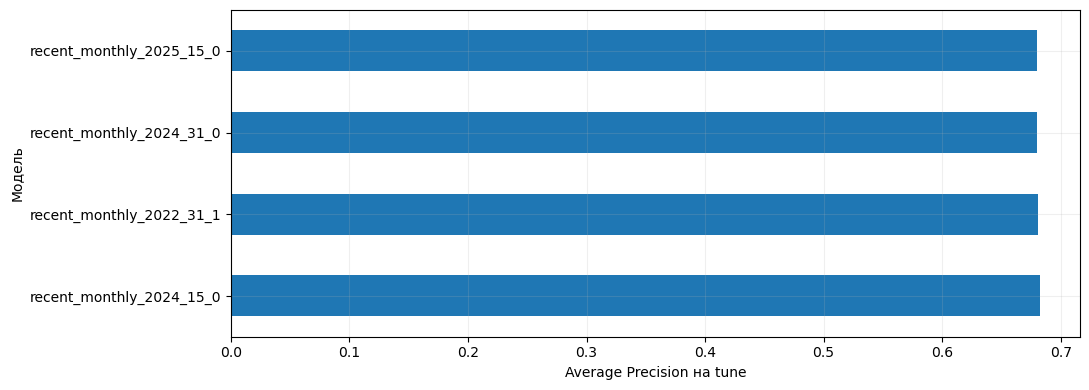

In [32]:
comparison.plot.barh(x='name',y='average_precision',legend=False)
plt.xlabel('Average Precision на tune');plt.ylabel('Модель');plt.tight_layout();plt.show()

Предпочитаем кандидатов с порогом, одновременно удовлетворяющим Precision > 0,7 и Recall > 0,5 на tune, затем выбираем максимальную AP. Это этап разработки. Подтверждением качества считаем только последующие блоки, с оговоркой о повторном использовании 2026 года.

## 5. Выбираем порог до расчёта проверки 2026 года

,rows,positives,prevalence,average_precision,roc_auc,precision,recall,f1,alerts,tp,fp,fn,tn,threshold
0,486154,24277,0.049937,0.586615,0.933331,0.625628,0.641348,0.63339,24887,15570,9317,8707,452560,0.431805


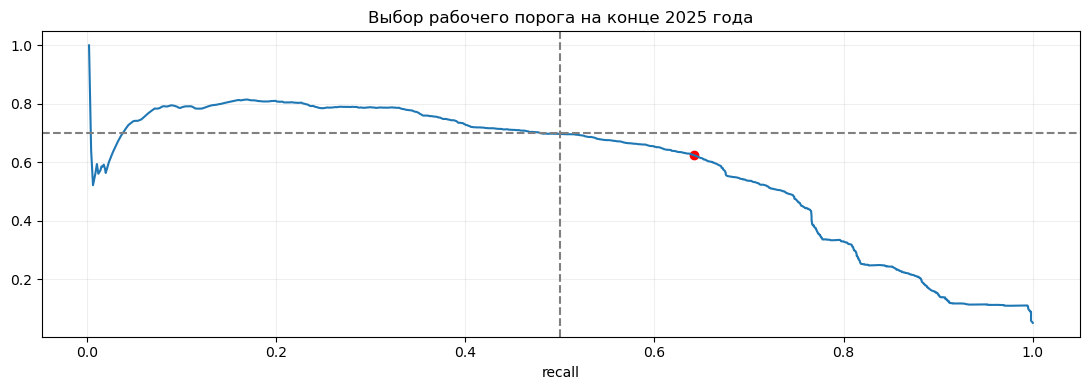

In [33]:
p_threshold=model.predict(feature_matrix(threshold_data,features),num_threads=8)
threshold,threshold_reason=select_threshold(threshold_data[TARGET],p_threshold)
validation_metrics=score_metrics(threshold_data[TARGET],p_threshold,threshold)
display(pd.DataFrame([validation_metrics]))
curve=threshold_table(threshold_data[TARGET],p_threshold)
curve.iloc[::max(1,len(curve)//1500)].plot(x='recall',y='precision',legend=False)
plt.scatter(validation_metrics['recall'],validation_metrics['precision'],color='red')
plt.axhline(.7,color='grey',linestyle='--');plt.axvline(.5,color='grey',linestyle='--')
plt.title('Выбор рабочего порога на конце 2025 года');plt.tight_layout();plt.show()

Отдельной калибровки в этой версии нет. Шкала риска является выходом LightGBM, рабочий порог выбран на следующем временном блоке. Если совместного порога нет, это фиксируется в отчёте; выполнение требований не подразумевается автоматически.

In [34]:
config={'name':winner,'kind':'lightgbm','model_version':'lct-monthly-recent-v1','feature_version':FEATURE_VERSION,
    'features':features,'base_features':base_features,'window_hours':[24,744],'target':TARGET,
    'threshold':threshold,'threshold_rule':threshold_reason,'calibration':{'coef':1.,'intercept':0.,'method':'identity'},
    'frozen_utc':pd.Timestamp.now(tz='UTC').isoformat(),'validation_metrics':validation_metrics,
    'scope':'any new registered episode in [t+24h,t+744h); not necessarily the first event after prediction',
    'evaluation_status':'retrospective re-evaluation; 2026 was already examined',
    'source_fingerprint':manifest.get('source_fingerprint')}
config['cache_data_key']=data_key
(OUT/'bundle/model.txt').write_text(model.model_to_string(), encoding='utf-8')
(OUT/'bundle/model_config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2),encoding='utf-8')
print('Модель и порог зафиксированы:',threshold)

Модель и порог зафиксированы: 0.4318047559853715


## 6. Ретроспективная проверка на 2026 годе

In [35]:
test=load_frame(prepare_monthly('test'),con)
assert (threshold_data.prediction_time+pd.Timedelta(days=31)).max()<=test.prediction_time.min()
full_test_rows=con.execute(f'SELECT count(*) FROM read_parquet({sql_path(HANDOFF/"ml_ready/test.parquet")})').fetchone()[0]
test_scope={'source_rows':full_test_rows,'retained_rows':len(test),'excluded_incomplete_future':full_test_rows-len(test),
    'first_prediction':str(test.prediction_time.min()),'last_prediction':str(test.prediction_time.max())}
display(pd.DataFrame([test_scope]))
X_test=feature_matrix(test,features)
p_test=model.predict(X_test,num_threads=8)
test_metrics=score_metrics(test[TARGET],p_test,threshold)
display(pd.DataFrame([test_metrics]))
intervals=cluster_intervals(test,p_test,threshold)
display(intervals)
intervals.to_csv(OUT/'reports/channel_bootstrap.csv',index=False)
test[['channel_id','prediction_time',TARGET,'next_start_after_24h']].assign(probability=p_test,alert=p_test>=threshold).to_parquet(OUT/'reports/test_predictions.parquet',index=False)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,source_rows,retained_rows,excluded_incomplete_future,first_prediction,last_prediction
0,1413660,1052914,360746,2026-01-01 00:00:00,2026-05-01 00:00:00


,rows,positives,prevalence,average_precision,roc_auc,precision,recall,f1,alerts,tp,fp,fn,tn,threshold
0,1052914,64824,0.061566,0.658549,0.947466,0.656702,0.655081,0.655891,64664,42465,22199,22359,965891,0.431805


,metric,low_95,high_95
0,precision,0.637003,0.677083
1,recall,0.628039,0.677949
2,f1,0.636070,0.674832


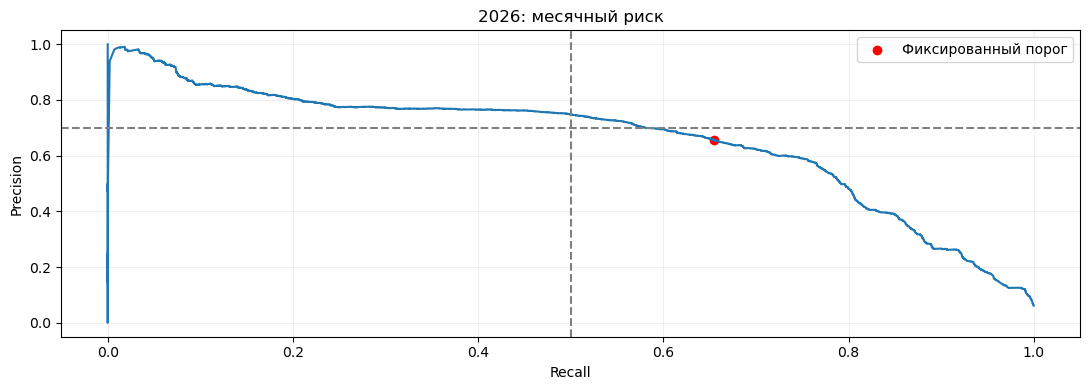

In [36]:
precision,recall,_=precision_recall_curve(test[TARGET],p_test)
plt.plot(recall,precision)
plt.scatter(test_metrics['recall'],test_metrics['precision'],color='red',label='Фиксированный порог')
plt.axhline(.7,color='grey',linestyle='--');plt.axvline(.5,color='grey',linestyle='--')
plt.xlabel('Recall');plt.ylabel('Precision');plt.legend();plt.title('2026: месячный риск');plt.tight_layout();plt.show()

Интервалы учитывают зависимость строк внутри канала, но не все общие объектные и временные причины. Пересекающиеся месячные окна создают зависимые примеры. Единица метрики здесь канал-дата прогноза, а не уникальная физическая авария.

Для месячного горизонта часть поздних дат 2026 года не имеет полного будущего окна. Выше показаны фактические границы и число исключённых строк. Их метки не заполняются нулями. Итог относится только к оставшейся наблюдаемой популяции и не описывает все каналы во все даты архива.

## 7. Проверяем смысл упреждения и ограничения окна

In [37]:
positive=test[TARGET].eq(1)
lead=(test.loc[positive,'next_start_after_24h']-test.loc[positive,'prediction_time']).dt.total_seconds()/3600
assert lead.between(24,744,inclusive='left').all()
display(lead.describe().to_frame('Часы до эпизода внутри целевого окна'))
true_alert=positive&(p_test>=threshold)
early_share=float(test.loc[true_alert,'target_fault_0_24h'].eq(1).mean())
display(Markdown(f'У **{early_share:.1%}** правильных предупреждений также был зарегистрирован эпизод в первых 24 часах. Мы прогнозируем наличие эпизода в заданном окне, а не гарантируем предупреждение самого первого следующего перехода.'))

,Часы до эпизода внутри целевого окна
count,64824.000000
mean,310.049276
std,210.321047
min,24.000278
25%,120.427500
50%,274.762917
75%,482.528889
max,743.477222


У **8.1%** правильных предупреждений также был зарегистрирован эпизод в первых 24 часах. Мы прогнозируем наличие эпизода в заданном окне, а не гарантируем предупреждение самого первого следующего перехода.

Если бизнес-требование относится именно к первому следующему физическому отказу, текущий таргет недостаточен и должен быть изменён до обучения. Для событий первых 24 часов нужен отдельный оперативный мониторинг. Численный результат ниже нельзя переносить на эту более строгую задачу.

## 8. Качество по месяцам и типам оборудования

,group,rows,positives,precision,recall
0,2026-01,287869,16665,0.692869,0.700270
1,2026-02,273733,14823,0.505406,0.548742
2,2026-03,258084,15816,0.690755,0.659965
3,2026-04,225937,17014,0.738196,0.694722
4,2026-05,7291,506,0.667219,0.796443


,group,rows,positives,precision,recall
13,Состояние вентилятора,33409,18394,0.770402,0.952050
3,Датчик дыма,384824,15798,0.431946,0.218762
14,Состояние насоса,17574,13714,0.780845,0.983885
16,Состояние фазы,92191,11453,0.500586,0.634506
11,Ручной извещатель,11499,2165,0.473094,0.194919
1,Газовый датчик,39288,1984,0.000000,0.000000
6,ИБП,7660,369,0.405583,0.669377
7,КД АВ,39618,351,0.000000,0.000000
2,Датчик движения,83691,253,0.368421,0.083004
8,КД Дверь,96941,123,0.000000,0.000000


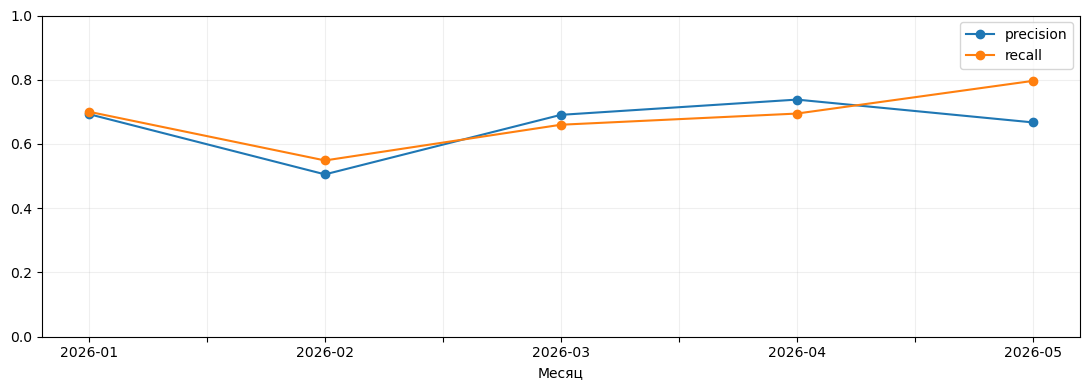

In [38]:
test['month_check']=test.prediction_time.dt.strftime('%Y-%m')
monthly=score_subgroups(test,p_test,threshold,'month_check')
types=score_subgroups(test,p_test,threshold,'sensor_type_current')
display(monthly[['group','rows','positives','precision','recall']])
display(types.sort_values('positives',ascending=False)[['group','rows','positives','precision','recall']].head(15))
monthly.to_csv(OUT/'reports/test_by_month.csv',index=False)
types.to_csv(OUT/'reports/test_by_type.csv',index=False)
monthly.plot(x='group',y=['precision','recall'],marker='o');plt.ylim(0,1)
plt.xlabel('Месяц');plt.tight_layout();plt.show()

Типы нужны только для диагностики по современному справочнику. Мы не исключаем типы с плохими результатами после оценки. Общие метрики не означают такое же качество для каждой категории.

## 9. Предупреждения и ошибки

,count,mean,std,min,25%,50%,75%,max
alert,121.0,534.413223,43.060746,460.0,495.0,542.0,572.0,616.0
false_alert,121.0,183.462810,71.875476,71.0,133.0,164.0,243.0,306.0


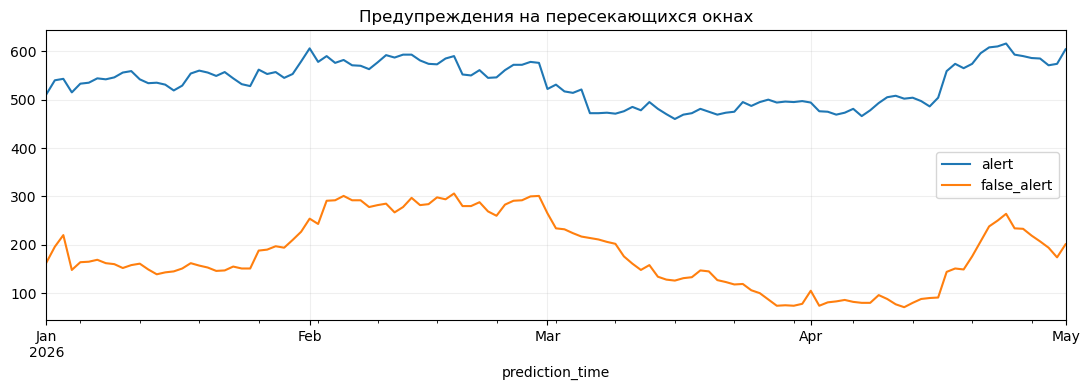

,channel_id,prediction_time,target_monthly,sensor_type_current,probability,alert,false_alert
224271,228571,2026-03-09,0,Датчик температуры,0.966549,True,True
492855,228571,2026-03-10,0,Датчик температуры,0.966549,True,True
969307,228571,2026-03-08,0,Датчик температуры,0.966549,True,True
920806,228571,2026-03-11,0,Датчик температуры,0.966514,True,True
1025,228571,2026-03-07,0,Датчик температуры,0.966383,True,True
408991,228571,2026-03-06,0,Датчик температуры,0.966383,True,True
4442,228571,2026-03-13,0,Датчик температуры,0.966348,True,True
494227,228571,2026-03-12,0,Датчик температуры,0.966348,True,True
527957,228571,2026-03-14,0,Датчик температуры,0.966101,True,True
700231,229697,2026-01-31,0,Состояние вентилятора,0.964668,True,True


,channel_id,prediction_time,target_monthly,sensor_type_current,probability,alert,false_alert
167376,228598,2026-03-04,1,Датчик температуры,0.000794,False,False
189876,228598,2026-03-05,1,Датчик температуры,0.000794,False,False
191471,228598,2026-03-08,1,Датчик температуры,0.000794,False,False
250319,228598,2026-02-27,1,Датчик температуры,0.000794,False,False
250961,228598,2026-02-28,1,Датчик температуры,0.000794,False,False
343423,228598,2026-02-24,1,Датчик температуры,0.000794,False,False
423908,228598,2026-03-01,1,Датчик температуры,0.000794,False,False
424112,228598,2026-03-02,1,Датчик температуры,0.000794,False,False
580860,228598,2026-02-23,1,Датчик температуры,0.000794,False,False
588209,228598,2026-03-03,1,Датчик температуры,0.000794,False,False


In [39]:
check=test[['channel_id','prediction_time',TARGET,'sensor_type_current']].copy()
check['probability']=p_test;check['alert']=p_test>=threshold
check['false_alert']=check.alert&check[TARGET].eq(0)
daily=check.groupby('prediction_time')[['alert','false_alert']].sum()
display(daily.describe().T)
daily.plot();plt.title('Предупреждения на пересекающихся окнах');plt.tight_layout();plt.show()
display(check[check.false_alert].nlargest(10,'probability'))
display(check[~check.alert&check[TARGET].eq(1)].nsmallest(10,'probability'))
check[check.alert.ne(check[TARGET].astype(bool))].to_parquet(OUT/'reports/errors.parquet',index=False)

Один канал может получать повторные ежедневные предупреждения об одном будущем эпизоде. Backend должен группировать их в одну активную карточку обслуживания. Метрики после такой группировки будут другими; текущие числа относятся к ежедневным прогнозам.

,feature,gain
72,fault_start_days_365d,889915.030697
83,hours_since_explicit_state,178566.289627
62,hours_since_fault_end,102030.173641
51,history_days,61529.281147
61,hours_since_fault_start,59176.518789
29,smoke_messages_30d,49938.467596
67,fault_starts_365d,24353.499592
90,events_per_active_day_30d,19303.238186
71,fault_start_days_90d,14394.205145
27,undefined_messages_30d,12375.238758


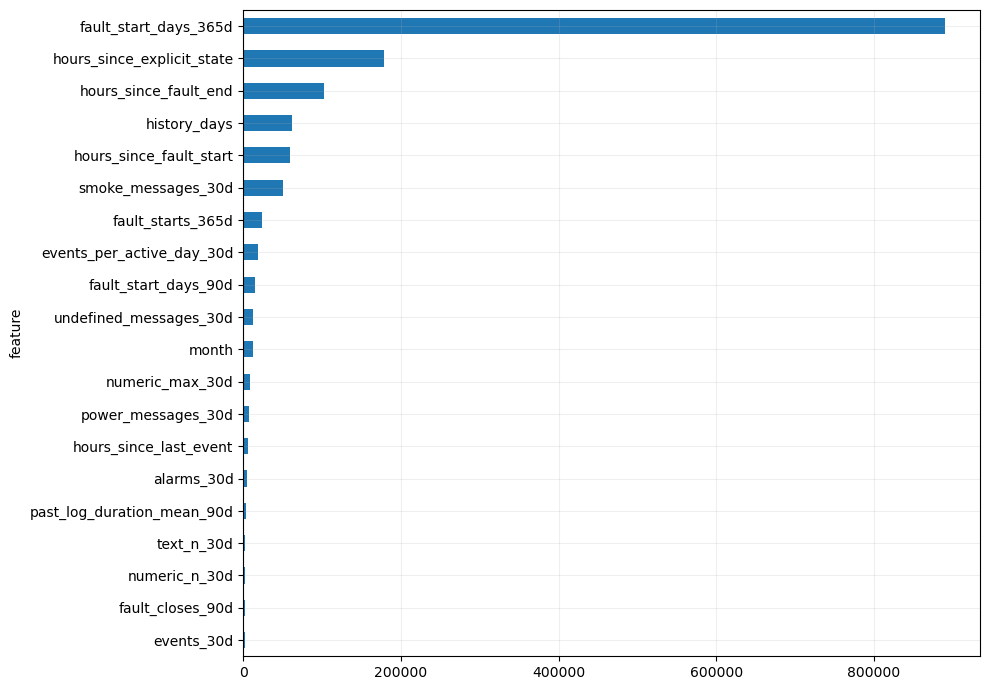

In [40]:
importance=pd.DataFrame({'feature':features,'gain':model.feature_importance(importance_type='gain')}).sort_values('gain',ascending=False)
display(importance.head(15))
importance.head(20).sort_values('gain').plot.barh(x='feature',y='gain',legend=False,figsize=(10,7));plt.tight_layout();plt.show()
importance.to_csv(OUT/'reports/feature_importance.csv',index=False)

## 10. Сохранённая модель и пакетный прогноз

In [41]:
latest=pd.read_parquet(HANDOFF/'ml_ready/scoring_latest.parquet')
started=time.perf_counter()
predictions=predict_batch(latest,episode_file,OUT/'bundle')
batch_seconds=time.perf_counter()-started
display(predictions.sort_values('risk_probability',ascending=False).head(12))
predictions.to_csv(OUT/'latest_predictions.csv',index=False)
predictions.to_parquet(OUT/'latest_predictions.parquet',index=False)
sample=test.head(100).copy()
reload=predict_batch(sample,episode_file,OUT/'bundle')
assert np.allclose(reload.risk_probability,p_test[:100],rtol=1e-5,atol=1e-6)
sample[TARGET]=1-sample[TARGET];sample['last_seen']=pd.Timestamp('2099-01-01')
invariant=predict_batch(sample,episode_file,OUT/'bundle')
assert np.allclose(reload.risk_probability,invariant.risk_probability)
assert (reload.target_end-reload.prediction_time).eq(pd.Timedelta(days=31)).all()
print('Строк:',len(latest),'секунд:',round(batch_seconds,3))

,channel_id,prediction_time,risk_probability,alert,status,model_version,target_start,target_end
4999,278072,2026-07-01,0.965990,True,scored,lct-monthly-recent-v1,2026-07-02,2026-08-01
1572,213447,2026-07-01,0.965275,True,scored,lct-monthly-recent-v1,2026-07-02,2026-08-01
7466,278073,2026-07-01,0.964614,True,scored,lct-monthly-recent-v1,2026-07-02,2026-08-01
7621,212862,2026-07-01,0.962424,True,scored,lct-monthly-recent-v1,2026-07-02,2026-08-01
172,213451,2026-07-01,0.962424,True,scored,lct-monthly-recent-v1,2026-07-02,2026-08-01
6907,212867,2026-07-01,0.962424,True,scored,lct-monthly-recent-v1,2026-07-02,2026-08-01
6516,212913,2026-07-01,0.962424,True,scored,lct-monthly-recent-v1,2026-07-02,2026-08-01
5888,212923,2026-07-01,0.962424,True,scored,lct-monthly-recent-v1,2026-07-02,2026-08-01
7381,212919,2026-07-01,0.962424,True,scored,lct-monthly-recent-v1,2026-07-02,2026-08-01
4189,212844,2026-07-01,0.962150,True,scored,lct-monthly-recent-v1,2026-07-02,2026-08-01


Строк: 8238 секунд: 1.549


Замер включает загрузку модели, прошлых эпизодов, дополнительные признаки и прогноз по готовым базовым признакам EDA. Первичная обработка сырого архива в него не входит. Последняя дата исходного архива относится к июню 2026 года; это исторический пример, а не текущий прогноз на дату запуска.

## 11. Итог и границы применимости

In [42]:
quality_pass=test_metrics['precision']>.7 and test_metrics['recall']>.5
display(pd.DataFrame([
    ['Precision > 0.7',test_metrics['precision'],test_metrics['precision']>.7],
    ['Recall > 0.5',test_metrics['recall'],test_metrics['recall']>.5],
    ['Упреждение до эпизода в целевом окне >=24 ч',float(lead.min()),bool(lead.min()>=24)],
    ['Прогноз готового пакета <300 секунд',batch_seconds,batch_seconds<300]
],columns=['criterion','value','passed']))
display(Markdown(f"Для **месячного риска зарегистрированного эпизода**: Precision **{test_metrics['precision']:.2%}**, Recall **{test_metrics['recall']:.2%}**. Совместное выполнение численных ориентиров: **{quality_pass}**. Это не результат для окна 24-48 часов и не независимая проверка физического отказа."))
report={'target':TARGET,'window_hours':[24,744],'model':winner,'threshold':threshold,
    'validation_metrics':validation_metrics,'test_metrics':test_metrics,'quality_pass':bool(quality_pass),
    'batch_seconds':batch_seconds,'batch_rows':len(latest),'early_event_share_among_true_alerts':early_share,
    'evaluation_status':config['evaluation_status'],'source_fingerprint':config['source_fingerprint']}
report['test_scope']=test_scope
(OUT/'training_report.json').write_text(json.dumps(report,ensure_ascii=False,indent=2),encoding='utf-8')
con.close()

,criterion,value,passed
0,Precision > 0.7,0.656702,False
1,Recall > 0.5,0.655081,True
2,Упреждение до эпизода в целевом окне >=24 ч,24.000278,True
3,Прогноз готового пакета <300 секунд,1.549303,True


Для **месячного риска зарегистрированного эпизода**: Precision **65.67%**, Recall **65.51%**. Совместное выполнение численных ориентиров: **False**. Это не результат для окна 24-48 часов и не независимая проверка физического отказа.

Для окончательного подтверждения нужны согласование горизонта планирования, связь эпизодов с реальными отказами и новый независимый период оценки. Планы ТО/ППР не используются без подтверждённой связи с объектами. Прежний суточный прогноз остаётся отдельным исследованием с невыполненными требованиями.

In [43]:
runtime_source='from pathlib import Path\nimport gc\nimport hashlib\nimport json\nimport time\nimport numpy as np\nimport pandas as pd\nimport duckdb\nfrom sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve\nfrom sklearn.metrics import precision_score, recall_score, f1_score, brier_score_loss, log_loss\nfrom sklearn.linear_model import LogisticRegression\n\nFEATURE_VERSION = \'episodes-past-v2\'\nTARGET = \'target_monthly\'\nEPISODE_WINDOWS = [1, 7, 30, 90, 365]\nFORBIDDEN = {\'last_seen\', \'target_fault_0_24h\', TARGET, \'channel_followup_48h\',\n             \'global_complete_24_48h\', \'target_start\', \'target_end\', \'sample_weight\',\n             \'sampling_probability\', \'sensor_type_current\', \'object_id_current\',\n             \'system_type_current\', \'channel_id\', \'prediction_time\'}\n\ndef sql_path(path):\n    return "\'" + str(path).replace(\'\\\\\', \'/\').replace("\'", "\'\'") + "\'"\n\ndef episode_tables(con, path):\n    con.execute(f"""CREATE OR REPLACE TEMP TABLE starts_prefix AS\n    WITH daily AS (\n      SELECT channel_id, CAST(start_ts AS DATE) AS day, count(*) AS n,\n             max(start_ts) AS last_start\n      FROM read_parquet({sql_path(path)}) WHERE observed_start\n      GROUP BY channel_id, CAST(start_ts AS DATE)\n    ) SELECT *, sum(n) OVER(PARTITION BY channel_id ORDER BY day) AS cumulative,\n        count(*) OVER(PARTITION BY channel_id ORDER BY day) AS cumulative_days\n      FROM daily ORDER BY channel_id, day""")\n    con.execute(f"""CREATE OR REPLACE TEMP TABLE closes_prefix AS\n    WITH daily AS (\n      SELECT channel_id, CAST(end_ts AS DATE) AS day, count(*) AS n,\n        count(*) FILTER(WHERE duration_hours <= 1.0/60) AS short_n,\n        sum(ln(1+duration_hours)) AS log_duration_sum, max(end_ts) AS last_close\n      FROM read_parquet({sql_path(path)})\n      WHERE observed_start AND end_ts IS NOT NULL AND duration_hours >= 0\n      GROUP BY channel_id, CAST(end_ts AS DATE)\n    ) SELECT *, sum(n) OVER w AS cumulative,\n        sum(short_n) OVER w AS short_cumulative,\n        sum(log_duration_sum) OVER w AS duration_cumulative\n      FROM daily WINDOW w AS (PARTITION BY channel_id ORDER BY day)\n      ORDER BY channel_id, day""")\n\ndef episode_select(source):\n    fields = ["r.*", "epoch(r.prediction_time-s0.last_start)/3600 AS hours_since_fault_start",\n              "epoch(r.prediction_time-c0.last_close)/3600 AS hours_since_fault_end",\n              "greatest(s0.last_start,c0.last_close) AS episode_feature_max_ts"]\n    joins = ["ASOF LEFT JOIN starts_prefix s0 ON r.channel_id=s0.channel_id AND r.prediction_time>s0.day",\n             "ASOF LEFT JOIN closes_prefix c0 ON r.channel_id=c0.channel_id AND r.prediction_time>c0.day"]\n    for days in EPISODE_WINDOWS:\n        fields.append(f"coalesce(s0.cumulative,0)-coalesce(s{days}.cumulative,0) AS fault_starts_{days}d")\n        fields.append(f"coalesce(s0.cumulative_days,0)-coalesce(s{days}.cumulative_days,0) AS fault_start_days_{days}d")\n        joins.append(f"ASOF LEFT JOIN starts_prefix s{days} ON r.channel_id=s{days}.channel_id AND r.prediction_time-INTERVAL {days} DAY>s{days}.day")\n    for days in [6, 13, 20, 27]:\n        fields.append(f"CASE WHEN w{days}.n IS NULL THEN 0 ELSE 1 END AS fault_day_lag_{days}")\n        joins.append(f"LEFT JOIN starts_prefix w{days} ON r.channel_id=w{days}.channel_id AND CAST(r.prediction_time-INTERVAL {days} DAY AS DATE)=w{days}.day")\n    for days in [30, 90]:\n        fields += [f"coalesce(c0.cumulative,0)-coalesce(c{days}.cumulative,0) AS fault_closes_{days}d",\n                   f"coalesce(c0.short_cumulative,0)-coalesce(c{days}.short_cumulative,0) AS short_fault_closes_{days}d",\n                   f"(coalesce(c0.duration_cumulative,0)-coalesce(c{days}.duration_cumulative,0))/nullif(coalesce(c0.cumulative,0)-coalesce(c{days}.cumulative,0),0) AS past_log_duration_mean_{days}d"]\n        joins.append(f"ASOF LEFT JOIN closes_prefix c{days} ON r.channel_id=c{days}.channel_id AND r.prediction_time-INTERVAL {days} DAY>c{days}.day")\n    return \'SELECT \' + \', \'.join(fields) + \' FROM \' + source + \' r \' + \' \'.join(joins)\n\ndef add_episode_file(con, source, destination):\n    source_sql = f\'read_parquet({sql_path(source)})\'\n    keys_sql = f\'(SELECT channel_id,prediction_time FROM {source_sql})\'\n    query = f\'WITH augmented AS ({episode_select(keys_sql)}) SELECT r.*, a.* EXCLUDE(channel_id,prediction_time) FROM {source_sql} r JOIN augmented a USING(channel_id,prediction_time)\'\n    temporary = Path(destination).with_suffix(\'.partial.parquet\')\n    con.execute(f\'COPY ({query}) TO {sql_path(temporary)} (FORMAT PARQUET, COMPRESSION ZSTD)\')\n    temporary.replace(destination)\n    bad = con.execute(f"SELECT count(*) FROM read_parquet({sql_path(destination)}) WHERE episode_feature_max_ts>=prediction_time").fetchone()[0]\n    if bad:\n        raise ValueError(\'Обнаружена будущая информация в признаках эпизодов\')\n\ndef augmented_feature_names(base_features):\n    episode = [\'hours_since_fault_start\', \'hours_since_fault_end\']\n    episode += [f\'fault_starts_{d}d\' for d in EPISODE_WINDOWS]\n    episode += [f\'fault_start_days_{d}d\' for d in EPISODE_WINDOWS]\n    episode += [f\'fault_day_lag_{d}\' for d in [6, 13, 20, 27]]\n    episode += [f\'{stem}_{d}d\' for d in [30, 90]\n                for stem in [\'fault_closes\', \'short_fault_closes\', \'past_log_duration_mean\']]\n    ratios = [\'hours_since_explicit_state\', \'alarm_share_1d\', \'fault_share_7d\',\n              \'undefined_share_7d\', \'night_share_7d\', \'numeric_share_7d\',\n              \'events_per_active_day_7d\', \'events_per_active_day_30d\',\n              \'numeric_range_7d\', \'numeric_range_30d\', \'short_fault_share_90d\',\n              \'fault_start_ratio_7d_30d\', \'fault_day_rate_30d\', \'fault_day_rate_90d\',\n              \'fault_day_rate_365d\', \'starts_per_fault_day_30d\', \'fault_weekly_repeats\']\n    result = list(dict.fromkeys(list(base_features) + episode + ratios))\n    if set(result) & FORBIDDEN:\n        raise ValueError(\'Служебное поле попало в признаки\')\n    return result\n\ndef feature_matrix(frame, names):\n    d = frame.copy(deep=False)\n    d = d.assign(hours_since_explicit_state=(pd.to_datetime(d[\'prediction_time\'])-pd.to_datetime(d[\'last_state_ts\'])).dt.total_seconds()/3600)\n    ratios = {\'alarm_share_1d\':(\'alarms_1d\',\'events_1d\'),\n              \'fault_share_7d\':(\'fault_messages_7d\',\'events_7d\'),\n              \'undefined_share_7d\':(\'undefined_messages_7d\',\'events_7d\'),\n              \'night_share_7d\':(\'night_events_7d\',\'events_7d\'),\n              \'numeric_share_7d\':(\'numeric_n_7d\',\'events_7d\'),\n              \'events_per_active_day_7d\':(\'events_7d\',\'active_days_7d\'),\n              \'events_per_active_day_30d\':(\'events_30d\',\'active_days_30d\'),\n              \'starts_per_fault_day_30d\':(\'fault_starts_30d\',\'fault_start_days_30d\'),\n              \'short_fault_share_90d\':(\'short_fault_closes_90d\',\'fault_closes_90d\')}\n    for name, (a,b) in ratios.items():\n        d[name] = d[a] / d[b].replace(0,np.nan)\n    for days in [7,30]:\n        d[f\'numeric_range_{days}d\'] = d[f\'numeric_max_{days}d\']-d[f\'numeric_min_{days}d\']\n    d[\'fault_start_ratio_7d_30d\'] = (d[\'fault_starts_7d\']/7)/(d[\'fault_starts_30d\']/30).replace(0,np.nan)\n    for days in [30, 90, 365]:\n        d[f\'fault_day_rate_{days}d\'] = d[f\'fault_start_days_{days}d\']/days\n    d[\'fault_weekly_repeats\'] = d[[f\'fault_day_lag_{days}\' for days in [6, 13, 20, 27]]].sum(axis=1)\n    x = d.loc[:,names].replace([np.inf,-np.inf],np.nan).astype(\'float32\')\n    if set(x) & FORBIDDEN:\n        raise ValueError(\'Запрещённый признак\')\n    return x\n\ndef load_frame(path, con, where=None):\n    q = f\'SELECT * FROM read_parquet({sql_path(path)})\'\n    if where:\n        q += \' WHERE \' + where\n    frame = con.execute(q).fetchdf()\n    for c in frame:\n        if frame[c].dtype == \'float64\':\n            frame[c] = frame[c].astype(\'float32\')\n    for c in [\'sensor_type_current\',\'object_id_current\',\'system_type_current\',\'last_explicit_state\']:\n        if c in frame:\n            frame[c] = frame[c].astype(\'category\')\n    return frame\n\ndef threshold_table(y, p):\n    precision, recall, thresholds = precision_recall_curve(y,p)\n    out = pd.DataFrame({\'threshold\':thresholds,\'precision\':precision[:-1],\'recall\':recall[:-1]})\n    out[\'f1\'] = 2*out.precision*out.recall/(out.precision+out.recall).replace(0,np.nan)\n    out[\'f1\'] = out[\'f1\'].fillna(0)\n    return out\n\ndef select_threshold(y,p):\n    t = threshold_table(y,p)\n    feasible = t.loc[(t.precision>0.7)&(t.recall>0.5)]\n    reason = \'precision>0.7 and recall>0.5\' if len(feasible) else \'max F1; joint requirement unattainable on this validation block\'\n    chosen = (feasible if len(feasible) else t).sort_values([\'f1\',\'precision\',\'recall\'],ascending=False).iloc[0]\n    return float(chosen.threshold),reason\n\ndef score_metrics(y,p,threshold):\n    y = np.asarray(y,dtype=int); p=np.asarray(p,dtype=float)\n    positive = p>=threshold\n    tp=int(np.sum(positive & (y==1))); fp=int(np.sum(positive & (y==0)))\n    fn=int(np.sum(~positive & (y==1))); tn=int(np.sum(~positive & (y==0)))\n    return {\'rows\':len(y),\'positives\':int(y.sum()),\'prevalence\':float(y.mean()),\n            \'average_precision\':float(average_precision_score(y,p)) if y.sum() else None,\n            \'roc_auc\':float(roc_auc_score(y,p)) if len(np.unique(y))==2 else None,\n            \'precision\':float(precision_score(y,positive,zero_division=0)),\n            \'recall\':float(recall_score(y,positive,zero_division=0)),\n            \'f1\':float(f1_score(y,positive,zero_division=0)),\n            \'alerts\':int(positive.sum()),\'tp\':tp,\'fp\':fp,\'fn\':fn,\'tn\':tn,\n            \'threshold\':float(threshold)}\n\ndef probability_metrics(y,p):\n    p=np.clip(np.asarray(p,dtype=float),1e-8,1-1e-8)\n    return {\'brier\':float(brier_score_loss(y,p)), \'log_loss\':float(log_loss(y,p,labels=[0,1]))}\n\ndef candidate_summary(y,p):\n    t=threshold_table(y,p)\n    at_p=t.loc[t.precision>0.7]\n    at_r=t.loc[t.recall>0.5]\n    return {\'average_precision\':float(average_precision_score(y,p)),\n            \'recall_at_precision_gt_07\':float(at_p.recall.max()) if len(at_p) else 0.,\n            \'precision_at_recall_gt_05\':float(at_r.precision.max()) if len(at_r) else 0.,\n            \'feasible\':bool(((t.precision>0.7)&(t.recall>0.5)).any()),\n            \'max_f1\':float(t.f1.max())}\n\ndef apply_calibration(p, calibration):\n    p=np.clip(np.asarray(p,dtype=float),1e-8,1-1e-8)\n    z=np.log(p/(1-p))*calibration[\'coef\']+calibration[\'intercept\']\n    return 1/(1+np.exp(-np.clip(z,-50,50)))\n\ndef fit_calibration(y,p):\n    clipped=np.clip(p,1e-8,1-1e-8)\n    z=np.log(clipped/(1-clipped)).reshape(-1,1)\n    model=LogisticRegression(C=10,max_iter=200,solver=\'lbfgs\').fit(z,y)\n    coefficient=float(model.coef_[0,0])\n    if coefficient<=0:\n        return {\'coef\':1.,\'intercept\':0.,\'method\':\'identity; fitted slope nonpositive\'}\n    return {\'coef\':coefficient,\'intercept\':float(model.intercept_[0]),\'method\':\'sigmoid logit, chronological calibration block\'}\n\ndef predict_probability(model, x, features, kind):\n    if kind==\'lightgbm_native\':\n        return np.asarray(model.predict(x[features],num_threads=8),dtype=\'float32\')\n    if kind==\'catboost\':\n        return np.asarray(model.predict_proba(x[features],thread_count=8)[:,1],dtype=\'float32\')\n    return np.asarray(model.predict_proba(x[features])[:,1],dtype=\'float32\')\n\ndef cluster_intervals(frame, p, threshold, repeats=400, seed=2026):\n    pred=np.asarray(p)>=threshold; y=frame[TARGET].to_numpy()\n    counts=pd.DataFrame({\'channel_id\':frame.channel_id.astype(str),\'tp\':pred&(y==1),\n                         \'fp\':pred&(y==0),\'fn\':~pred&(y==1)})\n    groups=counts.groupby(\'channel_id\')[[\'tp\',\'fp\',\'fn\']].sum().to_numpy(dtype=float)\n    rng=np.random.default_rng(seed); values=[]\n    for _ in range(repeats):\n        a,b,c=groups[rng.integers(0,len(groups),len(groups))].sum(axis=0)\n        precision=a/(a+b) if a+b else np.nan\n        recall=a/(a+c) if a+c else np.nan\n        values.append([precision,recall,2*a/(2*a+b+c) if 2*a+b+c else np.nan])\n    limits=np.nanquantile(values,[.025,.975],axis=0)\n    return pd.DataFrame({\'metric\':[\'precision\',\'recall\',\'f1\'],\'low_95\':limits[0],\'high_95\':limits[1]})\n\ndef reliability_table(y,p,bins=10):\n    df=pd.DataFrame({\'y\':np.asarray(y),\'p\':np.asarray(p)})\n    df[\'bin\']=pd.qcut(df.p,q=bins,duplicates=\'drop\')\n    return df.groupby(\'bin\',observed=True).agg(rows=(\'y\',\'size\'),mean_probability=(\'p\',\'mean\'),event_rate=(\'y\',\'mean\')).reset_index()\n\ndef score_subgroups(frame,p,threshold,column):\n    data=frame[[column,TARGET]].copy()\n    data[\'p\']=p\n    rows=[]\n    for group,part in data.groupby(column,observed=True,dropna=False):\n        rows.append({\'group\':str(group),**score_metrics(part[TARGET],part.p,threshold)})\n    return pd.DataFrame(rows)\n\ndef load_bundle(directory):\n    directory=Path(directory)\n    config=json.loads((directory/\'model_config.json\').read_text(encoding=\'utf-8\'))\n    if config.get(\'target\') != TARGET:\n        raise ValueError(\'Модель предназначена для другого таргета\')\n    if config[\'feature_version\'] != FEATURE_VERSION:\n        raise ValueError(\'Версия обработки признаков не совпадает с версией модели\')\n    if config[\'kind\']==\'lightgbm\':\n        import lightgbm as lgb\n        model=lgb.Booster(model_str=(directory/\'model.txt\').read_text(encoding=\'utf-8\'))\n        kind=\'lightgbm_native\'\n    elif config[\'kind\']==\'catboost\':\n        from catboost import CatBoostClassifier\n        model=CatBoostClassifier();model.load_model(str(directory/\'model.cbm\'))\n        kind=\'catboost\'\n    else:\n        import joblib\n        model=joblib.load(directory/\'model.joblib\');kind=\'logistic\'\n    return model,config,kind\n\ndef predict_batch(frame, episodes_path, model_directory):\n    model,config,kind=load_bundle(model_directory)\n    required=set(config[\'base_features\'])|{\'channel_id\',\'prediction_time\',\'last_state_ts\',\'at_risk_with_history\'}\n    missing=required-set(frame.columns)\n    if missing:\n        raise ValueError(\'Отсутствуют обязательные поля: \'+\', \'.join(sorted(missing)))\n    data=frame.copy()\n    data[\'prediction_time\']=pd.to_datetime(data.prediction_time)\n    data[\'last_state_ts\']=pd.to_datetime(data.last_state_ts)\n    if data.channel_id.isna().any():\n        raise ValueError(\'Идентификатор канала не должен быть пустым\')\n    if data.prediction_time.isna().any() or not (data.prediction_time==data.prediction_time.dt.normalize()).all():\n        raise ValueError(\'Нужен момент прогноза в полночь локального времени источника\')\n    if data.duplicated([\'channel_id\',\'prediction_time\']).any():\n        raise ValueError(\'Повторные ключи канал и момент прогноза\')\n    eligible=data.at_risk_with_history.eq(True)\n    if data.loc[eligible,\'last_state_ts\'].isna().any():\n        raise ValueError(\'Для применимого канала нужно время последнего явного состояния\')\n    if (data.loc[eligible,\'last_state_ts\']>=data.loc[eligible,\'prediction_time\']).any():\n        raise ValueError(\'Время состояния должно быть строго раньше прогноза\')\n    if \'feature_max_ts\' in data:\n        if (pd.to_datetime(data.loc[eligible,\'feature_max_ts\'])>=data.loc[eligible,\'prediction_time\']).any():\n            raise ValueError(\'Признаки содержат события после границы прогноза\')\n    answer=data[[\'channel_id\',\'prediction_time\']].copy()\n    answer[\'risk_probability\']=np.nan\n    answer[\'alert\']=pd.Series(pd.NA,index=answer.index,dtype=\'boolean\')\n    answer[\'status\']=np.where(eligible,\'scored\',\'not_eligible\')\n    answer[\'model_version\']=config[\'model_version\']\n    answer[\'target_start\']=answer.prediction_time+pd.Timedelta(hours=config[\'window_hours\'][0])\n    answer[\'target_end\']=answer.prediction_time+pd.Timedelta(hours=config[\'window_hours\'][1])\n    if eligible.any():\n        con=duckdb.connect()\n        con.execute("SET memory_limit=\'2GB\'");con.execute(\'SET threads=4\')\n        episode_tables(con,episodes_path)\n        selected=data.loc[eligible,list(config[\'base_features\'])+[\'channel_id\',\'prediction_time\',\'last_state_ts\']].reset_index(drop=True)\n        selected[\'__order\']=np.arange(len(selected))\n        con.register(\'request_rows\',selected)\n        enriched=con.execute(episode_select(\'request_rows\')+\' ORDER BY r.__order\').fetchdf()\n        x=feature_matrix(enriched,config[\'features\'])\n        raw=predict_probability(model,x,config[\'features\'],kind)\n        p=apply_calibration(raw,config[\'calibration\'])\n        answer.loc[eligible,\'risk_probability\']=p\n        answer.loc[eligible,\'alert\']=p>=config[\'threshold\']\n        con.close()\n    return answer\n\nFORBIDDEN |= {\'target_fault_24_48h\',\'target_fault_24_192h\',\'target_monthly\',\'next_start_after_24h\',\'monthly_weight\'}\n'
(OUT/"lct_planning.py").write_text(runtime_source,encoding="utf-8")

16498

In [44]:
import importlib.metadata
packages=['numpy','pandas','scikit-learn','duckdb','lightgbm','pyarrow','matplotlib','joblib']
(OUT/'requirements.txt').write_text('\n'.join(f'{p}=={importlib.metadata.version(p)}' for p in packages)+'\n',encoding='utf-8')
print('Файлы сохранены:',OUT)

Файлы сохранены: C:\Users\Redmi\OneDrive\Desktop\work\itmo\хакатоны\жкх\dataset\planning_artifacts
